# **Project Name**    - PhonePe Transaction Insights



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Pritam Das


# **Project Summary -**

This project focuses on analyzing PhonePe transaction data extracted
from the official PhonePe Pulse GitHub repository. PhonePe is one of
India's leading digital payment platforms and has been a major driver
of the UPI revolution in the country since its launch in 2016.

The dataset covers transaction data from 2018 to 2024 across all
states and union territories of India. The data is organized into
three main categories — aggregated transaction data, aggregated user
data and state level map transaction data. All data was extracted
from JSON files stored in a structured folder hierarchy and converted
into pandas DataFrames for analysis.

The aggregated transaction dataset contains 140 rows covering five
transaction types — Merchant payments, Peer-to-peer payments,
Recharge and bill payments, Financial Services and Others. Each row
represents a specific transaction type for a given year and quarter.
The aggregated user dataset contains 28 rows with registered user
counts and app open counts for each year and quarter. The map
transaction dataset contains 1008 rows covering transaction count
and amount for 36 states and union territories across all years
and quarters.

The analysis revealed several key findings. Transaction count and
transaction amount have both grown exponentially from 2018 to 2024.
Total transaction count grew nearly 10 times and total transaction
amount grew nearly 25 times over this period. This confirms that
digital payment adoption in India has been extraordinary over the
past seven years.

Merchant payments dominate in transaction count with a 55 percent
share while Peer-to-peer payments dominate in transaction amount
showing the highest average transaction value of around 3100 rupees
per transaction. This tells us that while people use PhonePe most
frequently for small merchant purchases, the highest value transfers
happen between individuals.

At the state level Maharashtra, Karnataka and Telangana lead in
both transaction count and amount. South Indian states show very
high digital payment adoption compared to northern and northeastern
states. States like Mizoram, Ladakh and Nagaland have very low
transaction counts indicating huge untapped markets.

Q4 is consistently the strongest quarter across all years driven
by the festive season in India. Q1 shows the lowest activity
suggesting a post festive slowdown every year.

Registered users have grown linearly from around 2500 lakhs in
2018 to over 22000 lakhs in 2024. App opens have grown much faster
than registered users showing very high daily engagement among
existing users.

As part of this project a SQLite database was created to store all
extracted data and SQL queries were written to answer key business
questions around top performing states, transaction type breakdowns
and yearly growth trends. An interactive Streamlit dashboard was
also developed to allow real time exploration of the data with
year and quarter filters, key metrics display and multiple
interactive charts.

The overall conclusion is that PhonePe is in a dominant position
in India's digital payment space and the data clearly shows
consistent growth across all metrics. The biggest opportunities
for future growth lie in expanding into underserved states,
growing the Financial Services segment and leveraging the
festive season more aggressively.


# **GitHub Link -**  https://github.com/Pritamdas16/pulse

# **Problem Statement**


PhonePe is one of India's leading digital payment platforms. With the increasing
reliance on digital payment systems, understanding the dynamics of transactions,
user engagement, and insurance-related data is crucial for improving services and
targeting users effectively.

This project aims to:
- Analyze aggregated values of payment categories across India
- Create geographical visualizations for total transaction values at state and
  district levels
- Identify top-performing states, districts, and pin codes
- Generate actionable business insights from transaction, user, and insurance data
  spanning from 2018 to 2024

The analysis will help stakeholders understand payment trends, user behavior,
and growth patterns in India's digital payment ecosystem.

#### **Define Your Business Objective?**

To extract meaningful insights from PhonePe's transaction data that can help
in customer segmentation, fraud detection, geographical targeting, and
improving user engagement and retention strategies.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
!git clone https://github.com/PhonePe/pulse.git

Cloning into 'pulse'...
remote: Enumerating objects: 17904, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 17904 (delta 19), reused 17 (delta 17), pack-reused 17855 (from 2)
Receiving objects: 100% (17904/17904), 26.13 MiB | 14.58 MiB/s, done.
Resolving deltas: 100% (8723/8723), done.
Updating files: 100% (9029/9029), done.


### Dataset Loading

In [3]:
# Load Dataset
# Load Dataset - Extract all JSON data into DataFrames

base_path = "/content/pulse/data"  # Colab path

# =============================================
# 1. AGGREGATED TRANSACTION
# =============================================
agg_trans = []
path = os.path.join(base_path, "aggregated", "transaction", "country", "india")

for year in os.listdir(path):
    year_path = os.path.join(path, year)
    if os.path.isdir(year_path) and year.isdigit():
        for file in os.listdir(year_path):
            if file.endswith(".json"):
                quarter = int(file.replace(".json", ""))
                with open(os.path.join(year_path, file)) as f:
                    data = json.load(f)
                    for item in data["data"]["transactionData"]:
                        agg_trans.append({
                            "year": int(year),
                            "quarter": quarter,
                            "transaction_type": item["name"],
                            "transaction_count": item["paymentInstruments"][0]["count"],
                            "transaction_amount": item["paymentInstruments"][0]["amount"]
                        })

df_agg_trans = pd.DataFrame(agg_trans)
print(f"✅ Aggregated Transaction: {df_agg_trans.shape}")

# =============================================
# 2. AGGREGATED USER
# =============================================
agg_user = []
path = os.path.join(base_path, "aggregated", "user", "country", "india")

for year in os.listdir(path):
    year_path = os.path.join(path, year)
    if os.path.isdir(year_path) and year.isdigit():
        for file in os.listdir(year_path):
            if file.endswith(".json"):
                quarter = int(file.replace(".json", ""))
                with open(os.path.join(year_path, file)) as f:
                    data = json.load(f)
                    users = data["data"]["aggregated"]
                    agg_user.append({
                        "year": int(year),
                        "quarter": quarter,
                        "registered_users": users["registeredUsers"],
                        "app_opens": users["appOpens"]
                    })

df_agg_user = pd.DataFrame(agg_user)
print(f"✅ Aggregated User: {df_agg_user.shape}")

# =============================================
# 3. MAP TRANSACTION (State Level)
# =============================================
map_trans = []
path = os.path.join(base_path, "map", "transaction", "hover", "country", "india")

for year in os.listdir(path):
    year_path = os.path.join(path, year)
    if os.path.isdir(year_path) and year.isdigit():
        for file in os.listdir(year_path):
            if file.endswith(".json"):
                quarter = int(file.replace(".json", ""))
                with open(os.path.join(year_path, file)) as f:
                    data = json.load(f)
                    for item in data["data"]["hoverDataList"]:
                        map_trans.append({
                            "year": int(year),
                            "quarter": quarter,
                            "state": item["name"],
                            "transaction_count": item["metric"][0]["count"],
                            "transaction_amount": item["metric"][0]["amount"]
                        })

df_map_trans = pd.DataFrame(map_trans)
print(f"✅ Map Transaction: {df_map_trans.shape}")

print("\n✅ All datasets loaded successfully!")

✅ Aggregated Transaction: (140, 5)
✅ Aggregated User: (28, 4)
✅ Map Transaction: (1008, 5)

✅ All datasets loaded successfully!


### Dataset First View

In [4]:
# Dataset First Look
print("--- Aggregated Transaction ---")
display(df_agg_trans.head())

print("--- Aggregated User ---")
display(df_agg_user.head())

print("--- Map Transaction ---")
display(df_map_trans.head())

--- Aggregated Transaction ---


,year,quarter,transaction_type,transaction_count,transaction_amount
0,2018,3,Peer-to-peer payments,202021587,4.259674e+11
1,2018,3,Recharge & bill payments,102290514,3.136431e+10
2,2018,3,Merchant payments,25175938,1.243315e+10
3,2018,3,Financial Services,6218596,8.914478e+08
4,2018,3,Others,5594554,4.449556e+09


--- Aggregated User ---


,year,quarter,registered_users,app_opens
0,2018,3,80010952,0
1,2018,2,63648311,0
2,2018,1,46877867,0
3,2018,4,102262055,0
4,2021,3,328354923,12256377890


--- Map Transaction ---


,year,quarter,state,transaction_count,transaction_amount
0,2018,3,puducherry,190271,4.176581e+08
1,2018,3,tamil nadu,15774078,2.933009e+10
2,2018,3,uttar pradesh,26515356,3.701211e+10
3,2018,3,madhya pradesh,17126985,2.414974e+10
4,2018,3,andhra pradesh,25626061,3.571804e+10


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count

print("Aggregated Transaction:", df_agg_trans.shape)
print("Aggregated User:", df_agg_user.shape)
print("Map Transaction:", df_map_trans.shape)


Aggregated Transaction: (140, 5)
Aggregated User: (28, 4)
Map Transaction: (1008, 5)


### Dataset Information

In [6]:
# Dataset Info
df_agg_trans.info()
print()
df_agg_user.info()
print()
df_map_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                140 non-null    int64  
 1   quarter             140 non-null    int64  
 2   transaction_type    140 non-null    object 
 3   transaction_count   140 non-null    int64  
 4   transaction_amount  140 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 5.6+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   year              28 non-null     int64
 1   quarter           28 non-null     int64
 2   registered_users  28 non-null     int64
 3   app_opens         28 non-null     int64
dtypes: int64(4)
memory usage: 1.0 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data 

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
print("Duplicates in Aggregated Transaction:", df_agg_trans.duplicated().sum())
print("Duplicates in Aggregated User:", df_agg_user.duplicated().sum())
print("Duplicates in Map Transaction:", df_map_trans.duplicated().sum())

Duplicates in Aggregated Transaction: 0
Duplicates in Aggregated User: 0
Duplicates in Map Transaction: 0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
print("Aggregated Transaction:")
print(df_agg_trans.isnull().sum())

print("\nAggregated User:")
print(df_agg_user.isnull().sum())

print("\nMap Transaction:")
print(df_map_trans.isnull().sum())

Aggregated Transaction:
year                  0
quarter               0
transaction_type      0
transaction_count     0
transaction_amount    0
dtype: int64

Aggregated User:
year                0
quarter             0
registered_users    0
app_opens           0
dtype: int64

Map Transaction:
year                  0
quarter               0
state                 0
transaction_count     0
transaction_amount    0
dtype: int64


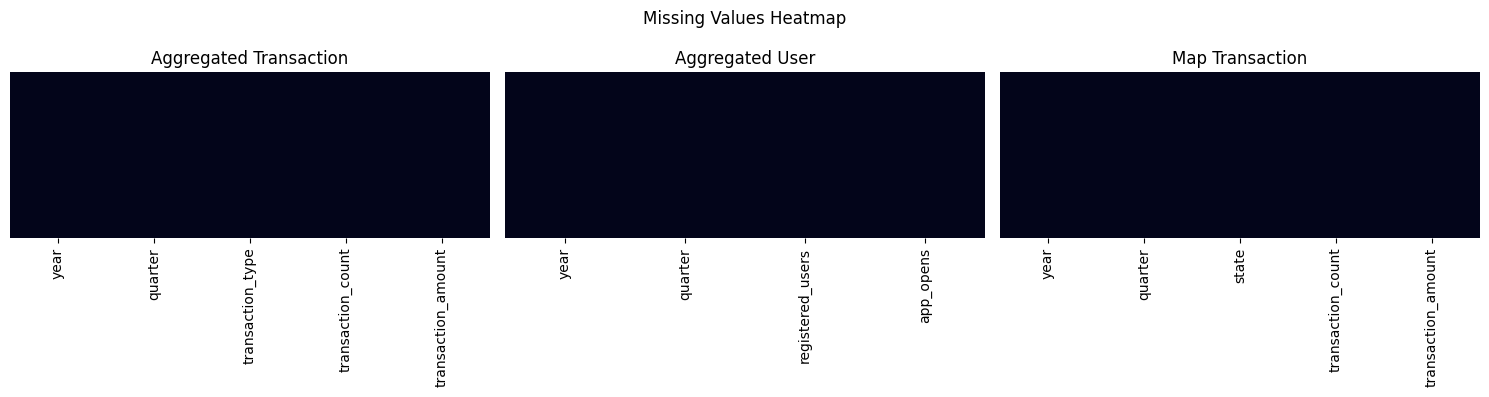

In [9]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(df_agg_trans.isnull(), cbar=False, ax=axes[0], yticklabels=False)
axes[0].set_title("Aggregated Transaction")

sns.heatmap(df_agg_user.isnull(), cbar=False, ax=axes[1], yticklabels=False)
axes[1].set_title("Aggregated User")

sns.heatmap(df_map_trans.isnull(), cbar=False, ax=axes[2], yticklabels=False)
axes[2].set_title("Map Transaction")

plt.suptitle("Missing Values Heatmap")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains three dataframes extracted from PhonePe Pulse GitHub repository.

- Aggregated Transaction has 140 rows and 5 columns covering transaction types,
  counts and amounts from 2018 to 2024 across all quarters.

- Aggregated User has 28 rows and 4 columns with registered users and app opens
  data year and quarter wise.

- Map Transaction has 1008 rows and 5 columns with state level transaction data
  including count and amount for each state across all years and quarters.

There are no missing values and no duplicate rows in any of the dataframes.
All columns have correct data types. The data is clean and ready for analysis.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print("Aggregated Transaction columns:", df_agg_trans.columns.tolist())
print("Aggregated User columns:", df_agg_user.columns.tolist())
print("Map Transaction columns:", df_map_trans.columns.tolist())

Aggregated Transaction columns: ['year', 'quarter', 'transaction_type', 'transaction_count', 'transaction_amount']
Aggregated User columns: ['year', 'quarter', 'registered_users', 'app_opens']
Map Transaction columns: ['year', 'quarter', 'state', 'transaction_count', 'transaction_amount']


In [11]:
# Dataset Describe
# statistical summary of each dataframe
print("--- Aggregated Transaction ---")
display(df_agg_trans.describe())

print("--- Aggregated User ---")
display(df_agg_user.describe())

print("--- Map Transaction ---")
display(df_map_trans.describe())

--- Aggregated Transaction ---


,year,quarter,transaction_count,transaction_amount
count,140.000000,140.000000,1.400000e+02,1.400000e+02
mean,2021.000000,2.500000,1.680606e+09,2.468027e+12
std,2.007181,1.122048,3.302734e+09,5.397846e+12
min,2018.000000,1.000000,1.358171e+06,5.453293e+08
25%,2019.000000,1.750000,8.441506e+06,6.384409e+09
50%,2021.000000,2.500000,2.042444e+08,1.197772e+11
75%,2023.000000,3.250000,1.372036e+09,1.430352e+12
max,2024.000000,4.000000,1.741919e+10,2.663387e+13


--- Aggregated User ---


,year,quarter,registered_users,app_opens
count,28.0000,28.00000,2.800000e+01,2.800000e+01
mean,2021.0000,2.50000,3.165794e+08,1.436751e+10
std,2.0367,1.13855,1.682795e+08,1.291694e+10
min,2018.0000,1.00000,4.687787e+07,0.000000e+00
25%,2019.0000,1.75000,1.735328e+08,4.087895e+09
50%,2021.0000,2.50000,3.168065e+08,1.094350e+10
75%,2023.0000,3.25000,4.585071e+08,2.342843e+10
max,2024.0000,4.00000,5.867565e+08,4.041638e+10


--- Map Transaction ---


,year,quarter,transaction_count,transaction_amount
count,1008.000000,1008.000000,1.008000e+03,1.008000e+03
mean,2021.000000,2.500000,2.334169e+08,3.427801e+11
std,2.000993,1.118589,5.143721e+08,7.030288e+11
min,2018.000000,1.000000,7.780000e+02,1.928611e+06
25%,2019.000000,1.750000,2.072062e+06,4.434177e+09
50%,2021.000000,2.500000,1.799364e+07,2.951822e+10
75%,2023.000000,3.250000,1.775121e+08,2.812155e+11
max,2024.000000,4.000000,3.634232e+09,4.151820e+12


### Variables Description

Aggregated Transaction (df_agg_trans):
- year: the year of the transaction (2018 to 2024)
- quarter: quarter of the year (1 to 4)
- transaction_type: category of payment like Recharge, Peer-to-peer, Merchant etc.
- transaction_count: total number of transactions in that category
- transaction_amount: total money transferred in that category

Aggregated User (df_agg_user):
- year: the year of the record
- quarter: quarter of the year
- registered_users: total number of users registered on PhonePe
- app_opens: total number of times the app was opened

Map Transaction (df_map_trans):
- year: the year of the transaction
- quarter: quarter of the year
- state: name of the Indian state
- transaction_count: total transactions in that state
- transaction_amount: total amount transacted in that state

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

for col in df_agg_trans.columns:
    print(f"df_agg_trans - {col}: {df_agg_trans[col].nunique()} unique values")

print()
for col in df_agg_user.columns:
    print(f"df_agg_user - {col}: {df_agg_user[col].nunique()} unique values")

print()
for col in df_map_trans.columns:
    print(f"df_map_trans - {col}: {df_map_trans[col].nunique()} unique values")

df_agg_trans - year: 7 unique values
df_agg_trans - quarter: 4 unique values
df_agg_trans - transaction_type: 5 unique values
df_agg_trans - transaction_count: 140 unique values
df_agg_trans - transaction_amount: 140 unique values

df_agg_user - year: 7 unique values
df_agg_user - quarter: 4 unique values
df_agg_user - registered_users: 28 unique values
df_agg_user - app_opens: 24 unique values

df_map_trans - year: 7 unique values
df_map_trans - quarter: 4 unique values
df_map_trans - state: 36 unique values
df_map_trans - transaction_count: 1008 unique values
df_map_trans - transaction_amount: 1008 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

# creating a year_quarter column for easier time series analysis
df_agg_trans["year_quarter"] = df_agg_trans["year"].astype(str) + " Q" + df_agg_trans["quarter"].astype(str)
df_agg_user["year_quarter"] = df_agg_user["year"].astype(str) + " Q" + df_agg_user["quarter"].astype(str)
df_map_trans["year_quarter"] = df_map_trans["year"].astype(str) + " Q" + df_map_trans["quarter"].astype(str)

# converting amount to crores for better readability
df_agg_trans["transaction_amount_cr"] = (df_agg_trans["transaction_amount"] / 1e7).round(2)
df_map_trans["transaction_amount_cr"] = (df_map_trans["transaction_amount"] / 1e7).round(2)

# converting registered users and app opens to lakhs
df_agg_user["registered_users_lakh"] = (df_agg_user["registered_users"] / 1e5).round(2)
df_agg_user["app_opens_lakh"] = (df_agg_user["app_opens"] / 1e5).round(2)

print("Data Wrangling done!")
display(df_agg_trans.head())
display(df_agg_user.head())
display(df_map_trans.head())

Data Wrangling done!


,year,quarter,transaction_type,transaction_count,transaction_amount,year_quarter,transaction_amount_cr
0,2018,3,Peer-to-peer payments,202021587,4.259674e+11,2018 Q3,42596.74
1,2018,3,Recharge & bill payments,102290514,3.136431e+10,2018 Q3,3136.43
2,2018,3,Merchant payments,25175938,1.243315e+10,2018 Q3,1243.32
3,2018,3,Financial Services,6218596,8.914478e+08,2018 Q3,89.14
4,2018,3,Others,5594554,4.449556e+09,2018 Q3,444.96


,year,quarter,registered_users,app_opens,year_quarter,registered_users_lakh,app_opens_lakh
0,2018,3,80010952,0,2018 Q3,800.11,0.00
1,2018,2,63648311,0,2018 Q2,636.48,0.00
2,2018,1,46877867,0,2018 Q1,468.78,0.00
3,2018,4,102262055,0,2018 Q4,1022.62,0.00
4,2021,3,328354923,12256377890,2021 Q3,3283.55,122563.78


,year,quarter,state,transaction_count,transaction_amount,year_quarter,transaction_amount_cr
0,2018,3,puducherry,190271,4.176581e+08,2018 Q3,41.77
1,2018,3,tamil nadu,15774078,2.933009e+10,2018 Q3,2933.01
2,2018,3,uttar pradesh,26515356,3.701211e+10,2018 Q3,3701.21
3,2018,3,madhya pradesh,17126985,2.414974e+10,2018 Q3,2414.97
4,2018,3,andhra pradesh,25626061,3.571804e+10,2018 Q3,3571.80


### What all manipulations have you done and insights you found?

Three new columns were added to make analysis easier.

A year_quarter column was created by combining year and quarter
so that time series charts are easier to plot and read.

Transaction amounts were converted from raw rupees to crores
since the original values were in scientific notation and hard to interpret.

Registered users and app opens were converted to lakhs for the same reason.
This makes the numbers more readable in charts and summaries.

No rows were dropped and no values were changed.
Only new derived columns were added on top of the existing data.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

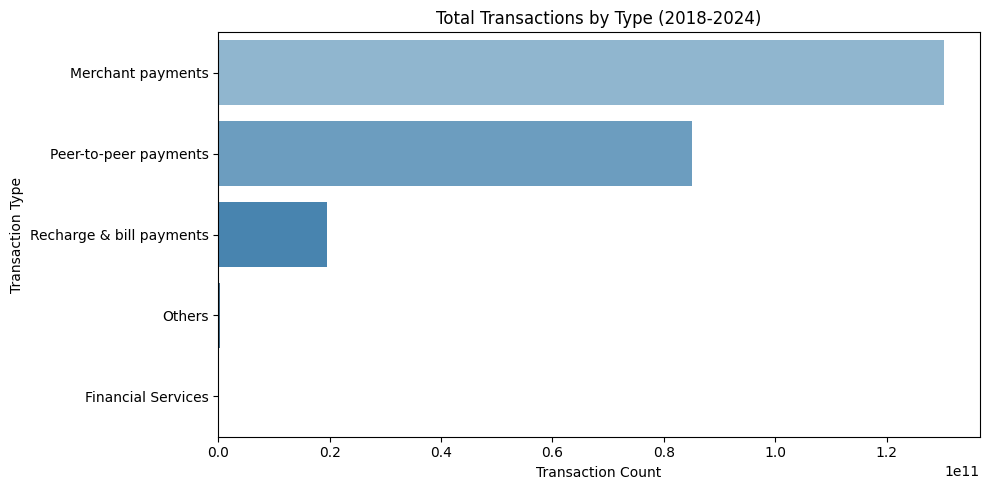

In [14]:
# Chart - 1 visualization code
# total transaction count by type - bar chart
plt.figure(figsize=(10, 5))

type_data = df_agg_trans.groupby("transaction_type")["transaction_count"].sum().sort_values(ascending=False)

sns.barplot(x=type_data.values, y=type_data.index, palette="Blues_d")

plt.title("Total Transactions by Type (2018-2024)")
plt.xlabel("Transaction Count")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart makes it easy to compare transaction volumes
across different payment categories. The labels are clearly readable
and the length of bars directly shows the difference in scale.

##### 2. What is/are the insight(s) found from the chart?

Merchant payments dominate with the highest transaction count,
followed by Peer-to-peer payments. Recharge & bill payments come
in third. Financial Services and Others have very low volumes
compared to the top two categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights are helpful for business growth.

Merchant payments being the highest shows that PhonePe has successfully
penetrated the retail and small business market. This is a positive sign
and the platform should keep investing in merchant acquisition and offers.

Peer-to-peer payments being second shows strong user to user trust
which helps in organic growth through word of mouth.

The negative signal here is that Financial Services is extremely low.
This means users are not using PhonePe for loans, insurance or investments.
If this trend continues PhonePe may lose this segment to competitors
like Groww or Policybazaar. PhonePe needs to actively promote these
services to avoid losing market share in the fintech space.

#### Chart - 2

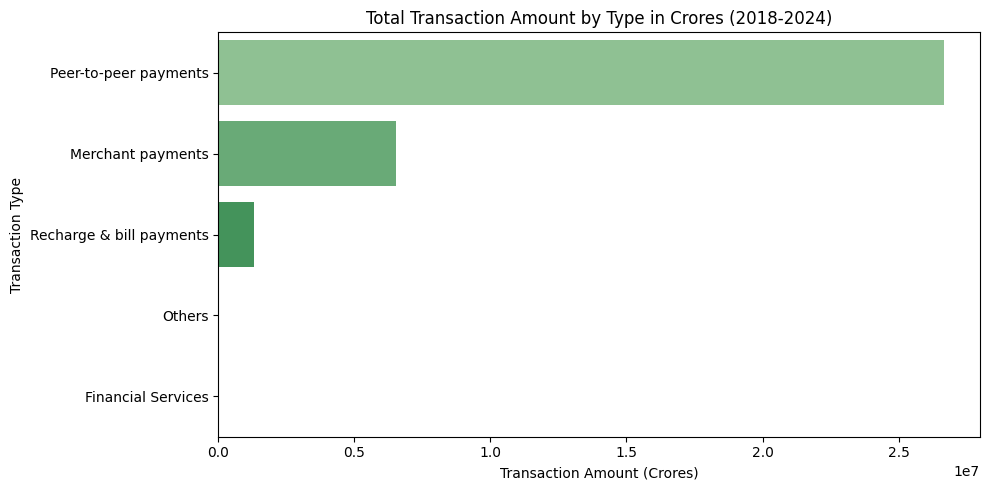

In [15]:
# Chart - 2 visualization code

# total transaction amount by type - bar chart
plt.figure(figsize=(10, 5))

amount_data = df_agg_trans.groupby("transaction_type")["transaction_amount_cr"].sum().sort_values(ascending=False)

sns.barplot(x=amount_data.values, y=amount_data.index, palette="Greens_d")

plt.title("Total Transaction Amount by Type in Crores (2018-2024)")
plt.xlabel("Transaction Amount (Crores)")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Same bar chart style but this time for transaction amount instead of count.
This helps compare which category moves the most money vs which has
the most number of transactions.

##### 2. What is/are the insight(s) found from the chart?

Peer-to-peer payments leads in total amount even though Merchant payments
led in transaction count. This means P2P transactions are fewer in number
but each transaction involves a much larger sum of money. Merchant payments
are high in count but smaller in individual value — people use it for
small daily purchases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This count vs amount gap is a very important business insight.

P2P transactions carry the most money which means PhonePe must ensure
high security and reliability for these transfers as any failure here
would directly impact user trust.

Merchant payments have high count but low amount per transaction —
this is good for daily engagement but PhonePe earns less per transaction.
To improve revenue PhonePe should push premium merchant services and
subscription models.

Financial Services being near zero in both charts is a consistent
negative signal that needs urgent attention from the product team.

#### Chart - 3

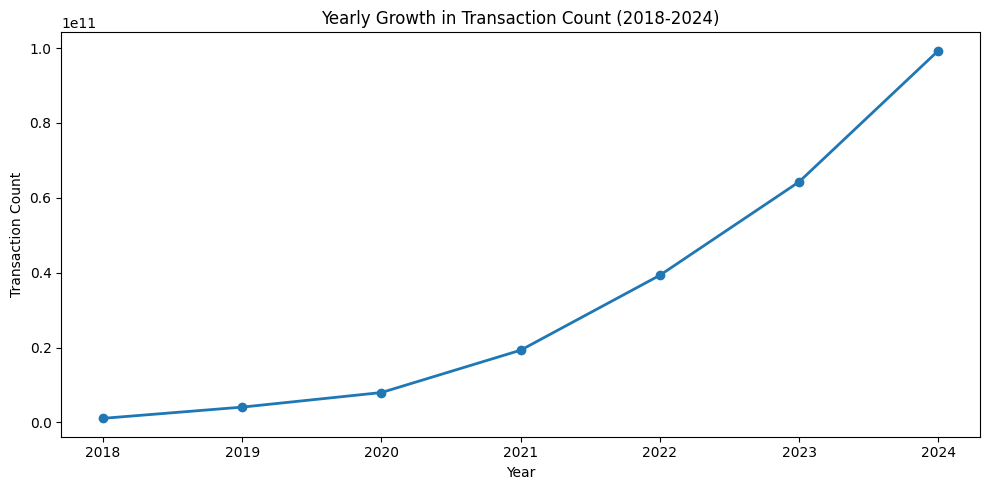

In [16]:
# Chart - 3 visualization code

# yearly growth in transaction count - line chart
plt.figure(figsize=(10, 5))

yearly_data = df_agg_trans.groupby("year")["transaction_count"].sum()

plt.plot(yearly_data.index, yearly_data.values, marker="o", linewidth=2)

plt.title("Yearly Growth in Transaction Count (2018-2024)")
plt.xlabel("Year")
plt.ylabel("Transaction Count")
plt.xticks(yearly_data.index)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the best way to show growth over time.
It clearly shows the trend and direction of transaction
volume year by year from 2018 to 2024.

##### 2. What is/are the insight(s) found from the chart?

Transaction count has grown exponentially from 2018 to 2024.
Growth was slow initially but picked up sharply after 2020.
By 2024 the count is nearly 10 times what it was in 2018.
This shows massive adoption of PhonePe across India over the years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a very positive signal for the business. The exponential
growth curve shows that PhonePe has successfully scaled its platform
and user base year on year.

The sharp growth after 2021 likely coincides with post-COVID digital
payment adoption across India. This trend suggests PhonePe should
keep investing in infrastructure to handle the growing transaction load.

There is no negative signal here but the company must ensure that
server capacity and security scale equally fast to match this growth,
otherwise system failures during peak load could damage user trust.

#### Chart - 4

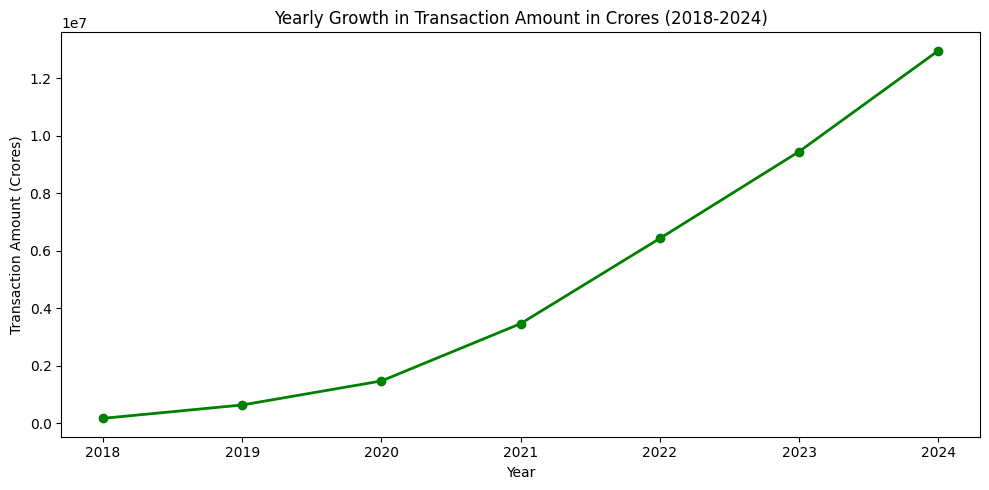

In [17]:
# Chart - 4 visualization code

# yearly growth in transaction amount - line chart
plt.figure(figsize=(10, 5))

yearly_amount = df_agg_trans.groupby("year")["transaction_amount_cr"].sum()

plt.plot(yearly_amount.index, yearly_amount.values, marker="o", color="green", linewidth=2)

plt.title("Yearly Growth in Transaction Amount in Crores (2018-2024)")
plt.xlabel("Year")
plt.ylabel("Transaction Amount (Crores)")
plt.xticks(yearly_amount.index)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen to show how the total transaction amount
has grown over the years. It clearly shows the upward trend and
the rate of growth between each year from 2018 to 2024.

##### 2. What is/are the insight(s) found from the chart?

Transaction amount has grown exponentially similar to transaction count.
The growth accelerated sharply after 2020 and by 2024 the total amount
is nearly 25 times compared to 2018. This shows not only more transactions
are happening but people are also transacting larger amounts over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights point towards strong positive business growth.

The exponential rise in transaction amount shows that PhonePe users
are not just doing more transactions but are also trusting the platform
with larger sums of money. This builds a strong case for PhonePe to
introduce premium financial products like fixed deposits, mutual funds
and high value insurance plans.

The negative concern here is that the Y axis shows values in the range
of 10 to the power 7 crores which is an extremely large number. If the
growth rate slows down suddenly due to competition from GPay or Paytm
or due to regulatory changes by RBI, the business could face a sharp
drop in GMV. PhonePe should diversify its revenue streams beyond
just transaction fees to avoid this risk.

#### Chart - 5

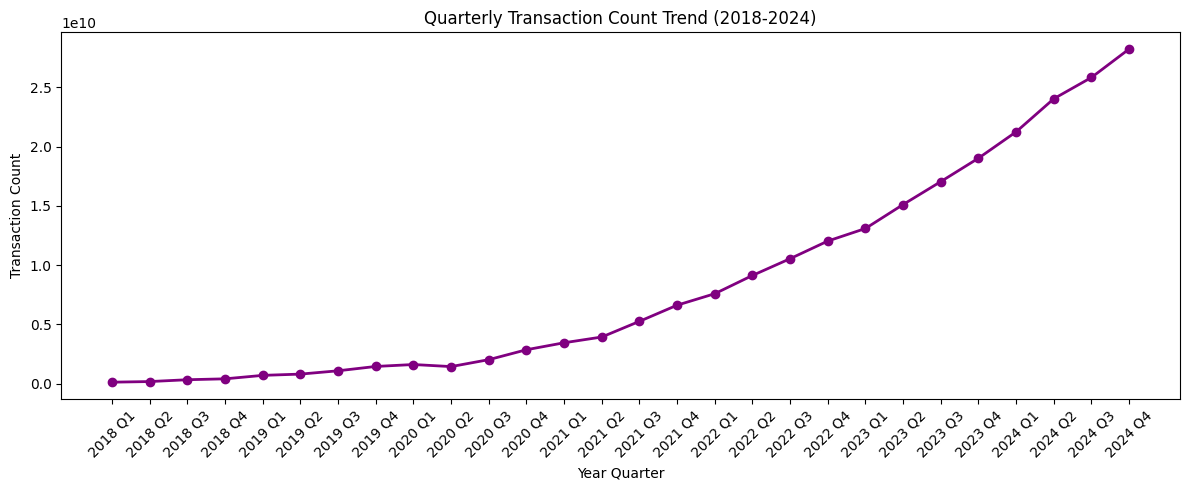

In [18]:
# Chart - 5 visualization code

# quarterly transaction count trend - line chart
plt.figure(figsize=(12, 5))

quarterly_data = df_agg_trans.groupby("year_quarter")["transaction_count"].sum()

plt.plot(quarterly_data.index, quarterly_data.values, marker="o", color="purple", linewidth=2)

plt.title("Quarterly Transaction Count Trend (2018-2024)")
plt.xlabel("Year Quarter")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart with quarterly granularity was chosen to see the growth
pattern in more detail than yearly. This helps identify if growth
is consistent across all quarters or if there are any seasonal dips.

##### 2. What is/are the insight(s) found from the chart?

The growth is very consistent quarter on quarter with no major dips
visible. The curve is smooth and exponential which means PhonePe has
been growing steadily every single quarter from 2018 to 2024.
There is no seasonal slowdown visible in any particular quarter.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Consistent quarter on quarter growth without any dips shows
that PhonePe has a very stable and loyal user base. This gives
confidence to investors and stakeholders that the platform is
not dependent on seasonal events or festivals for growth.

The only concern is that the curve is starting to look very steep
towards 2024. If infrastructure does not scale proportionally,
the platform may face downtime or slowness during peak quarters
which would negatively impact user experience and trust.

#### Chart - 6

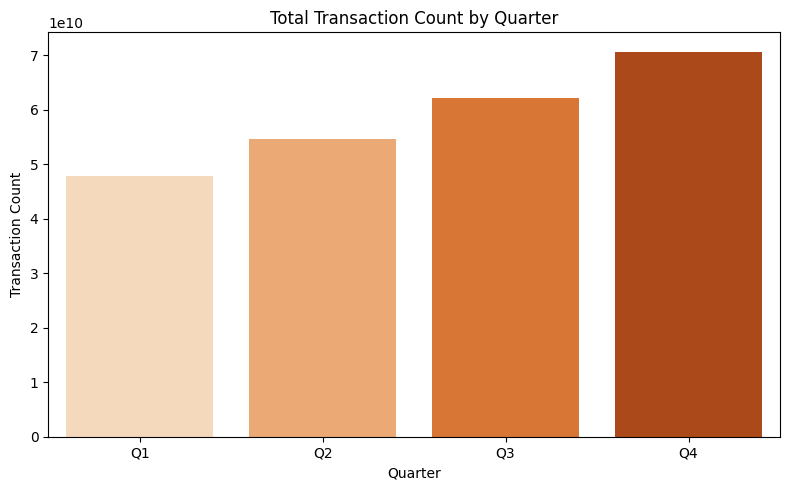

In [19]:
# Chart - 6 visualization code
# transaction count by quarter - box plot to see seasonal pattern
plt.figure(figsize=(8, 5))

quarter_data = df_agg_trans.groupby("quarter")["transaction_count"].sum()

sns.barplot(x=quarter_data.index, y=quarter_data.values, palette="Oranges")

plt.title("Total Transaction Count by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Transaction Count")
plt.xticks([0,1,2,3], ["Q1", "Q2", "Q3", "Q4"])
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare total transaction count across
the four quarters. This helps identify if there is any seasonal
pattern in user behavior throughout the year.

##### 2. What is/are the insight(s) found from the chart?

Q4 has the highest transaction count followed by Q3, Q2 and Q1.
This shows a clear pattern where transactions increase as the year
progresses. Q4 being the highest likely corresponds to the festive
season in India — Diwali, Durga Puja and year end shopping drive
more digital payments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing that Q4 is the peak quarter allows PhonePe to plan
its marketing campaigns, cashback offers and server scaling
specifically around the festive season to maximize growth.

Q1 being the lowest is a negative signal — it suggests a post
festive slowdown in transactions. PhonePe can counter this by
launching special Q1 promotions or new year offers to keep
user engagement high during the slow months.

#### Chart - 7

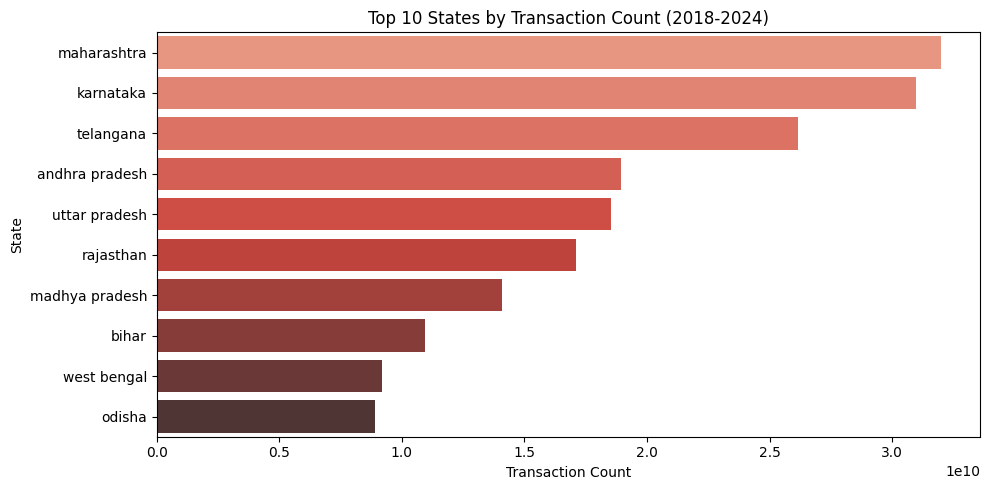

In [20]:
# Chart - 7 visualization code

# top 10 states by transaction count - bar chart
plt.figure(figsize=(10, 5))

state_data = df_map_trans.groupby("state")["transaction_count"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=state_data.values, y=state_data.index, palette="Reds_d")

plt.title("Top 10 States by Transaction Count (2018-2024)")
plt.xlabel("Transaction Count")
plt.ylabel("State")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen to compare transaction counts
across states. Horizontal layout makes state names clearly readable
and easy to rank visually.

##### 2. What is/are the insight(s) found from the chart?

Maharashtra leads in transaction count followed closely by Karnataka
and Telangana. These three states alone account for a massive share
of total transactions. South Indian states like Karnataka, Telangana
and Andhra Pradesh are strongly represented showing high digital
payment adoption in southern India. West Bengal and Odisha appear
in the bottom of the top 10 showing moderate adoption.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Maharashtra and Karnataka being the top states makes sense
as they are major metro hubs with high smartphone and internet
penetration. PhonePe should continue investing in these markets
to maintain dominance.

The negative signal is that large population states like Uttar Pradesh
and Bihar are lower in the list despite having huge populations.
This indicates low digital payment penetration in Hindi heartland states.
PhonePe can target these states with vernacular language support,
rural merchant onboarding and simplified UX to unlock a massive
untapped market.

#### Chart - 8

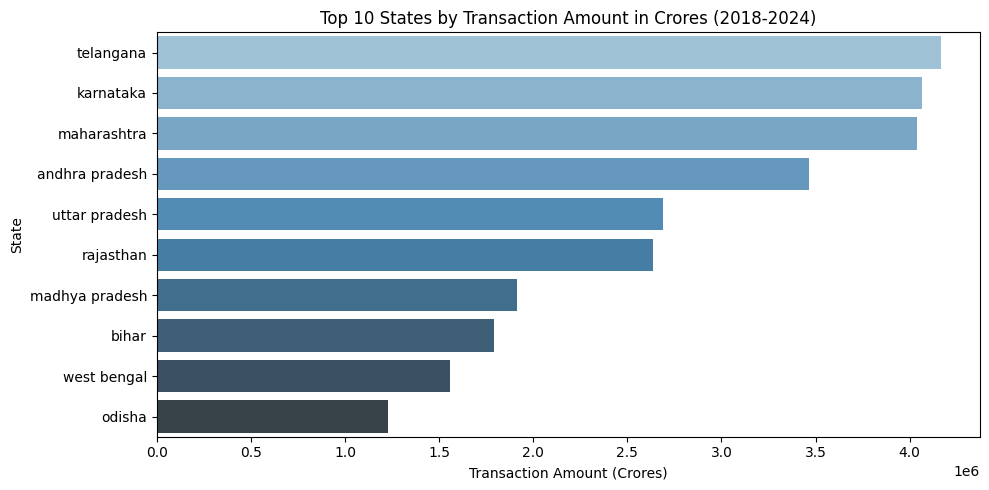

In [21]:
# Chart - 8 visualization code

# top 10 states by transaction amount - bar chart
plt.figure(figsize=(10, 5))

state_amount = df_map_trans.groupby("state")["transaction_amount_cr"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=state_amount.values, y=state_amount.index, palette="Blues_d")

plt.title("Top 10 States by Transaction Amount in Crores (2018-2024)")
plt.xlabel("Transaction Amount (Crores)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Same horizontal bar chart but for transaction amount instead of count.
Comparing this with the previous chart helps identify which states
transact more money vs which states transact more frequently.

##### 2. What is/are the insight(s) found from the chart?

Telangana tops in transaction amount even though Maharashtra led
in transaction count. This means Telangana users do fewer but
higher value transactions. Karnataka and Maharashtra follow closely.
The same 10 states appear in both charts but the ranking has shifted
showing that transaction frequency and transaction value do not
always go hand in hand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Telangana leading in amount suggests a high concentration of
business and corporate payments in Hyderabad. PhonePe should focus
on B2B payment solutions and enterprise products in Telangana
to capture this high value segment.

The negative signal is that West Bengal and Odisha are at the bottom
in both count and amount charts. These are densely populated states
with low digital payment adoption. Without targeted intervention
PhonePe risks losing these markets to local competitors or UPI
alternatives. Regional language campaigns and offline merchant
drives could help improve numbers here.

#### Chart - 9

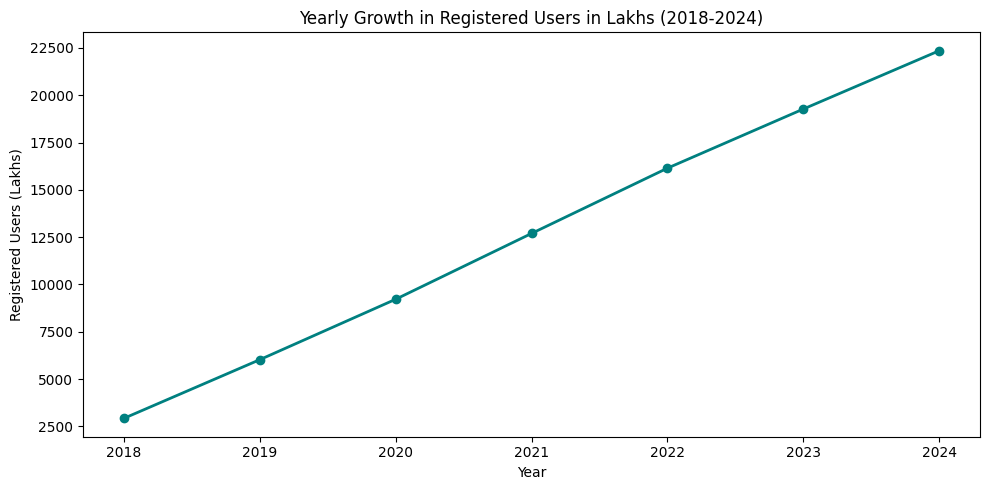

In [22]:
# Chart - 9 visualization code

# registered users growth over the years - line chart
plt.figure(figsize=(10, 5))

user_growth = df_agg_user.groupby("year")["registered_users_lakh"].sum()

plt.plot(user_growth.index, user_growth.values, marker="o", color="teal", linewidth=2)

plt.title("Yearly Growth in Registered Users in Lakhs (2018-2024)")
plt.xlabel("Year")
plt.ylabel("Registered Users (Lakhs)")
plt.xticks(user_growth.index)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen to track registered user growth over the years.
This helps understand how fast PhonePe is acquiring new users
and whether the growth is consistent or slowing down.

##### 2. What is/are the insight(s) found from the chart?

Registered users have grown in a very consistent linear fashion
from around 2500 lakhs in 2018 to over 22000 lakhs in 2024.
Unlike transaction count which grew exponentially, user growth
is steady and linear. By 2024 PhonePe has over 220 crore
registered users which is remarkable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Consistent linear user growth shows that PhonePe has a
reliable user acquisition engine running year on year.
This steady growth is attractive to investors as it shows
the platform is not dependent on viral spikes.

The negative concern here is that the growth is linear while
transaction count is exponential. This means existing users
are transacting more and more rather than new users driving growth.
While this is good for engagement, PhonePe must ensure new user
acquisition does not plateau, especially in rural and semi-urban
markets where smartphone adoption is still growing.

#### Chart - 10

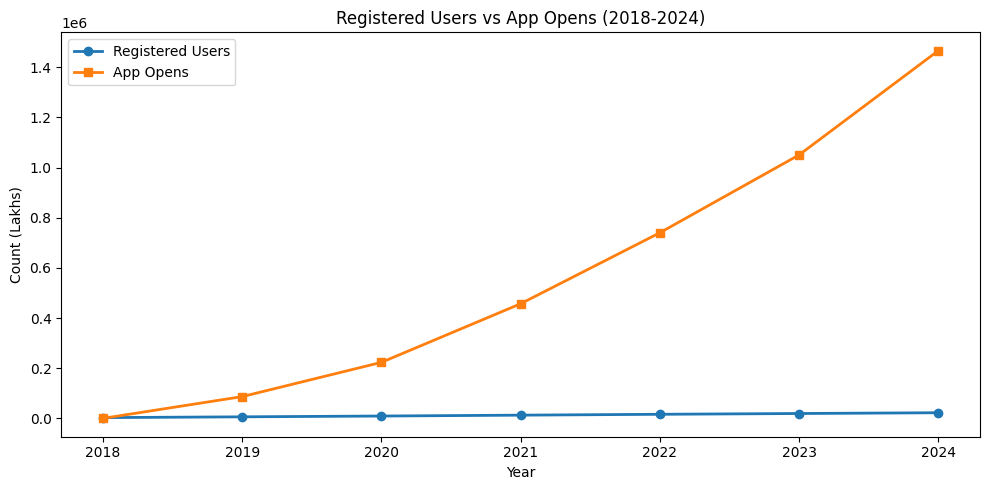

In [23]:
# Chart - 10 visualization code

# app opens vs registered users over the years - dual line chart
plt.figure(figsize=(10, 5))

user_data = df_agg_user.groupby("year")[["registered_users_lakh", "app_opens_lakh"]].sum()

plt.plot(user_data.index, user_data["registered_users_lakh"], marker="o", label="Registered Users", linewidth=2)
plt.plot(user_data.index, user_data["app_opens_lakh"], marker="s", label="App Opens", linewidth=2)

plt.title("Registered Users vs App Opens (2018-2024)")
plt.xlabel("Year")
plt.ylabel("Count (Lakhs)")
plt.xticks(user_data.index)
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A dual line chart was chosen to compare registered users and app opens
on the same graph. This helps understand user engagement — whether
registered users are actively using the app or just signing up and leaving.

##### 2. What is/are the insight(s) found from the chart?

App opens have grown exponentially and are massively higher than
registered users. This means each registered user is opening the app
multiple times which shows very high engagement and daily active usage.
The gap between the two lines keeps widening every year showing that
existing users are becoming more and more active over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a very positive signal for the business. High app opens per
user means PhonePe has successfully made itself a daily habit for
its users. This level of engagement is extremely valuable as it
gives PhonePe multiple opportunities to cross-sell products like
insurance, loans and investments every time a user opens the app.

The only concern is that app opens data shows zero for 2018 and 2019
which likely means the data was not tracked in early years.
This is a data quality issue and not a business problem.
PhonePe should ensure consistent data collection across all years
for better historical analysis.

#### Chart - 11

<Figure size 1200x600 with 0 Axes>

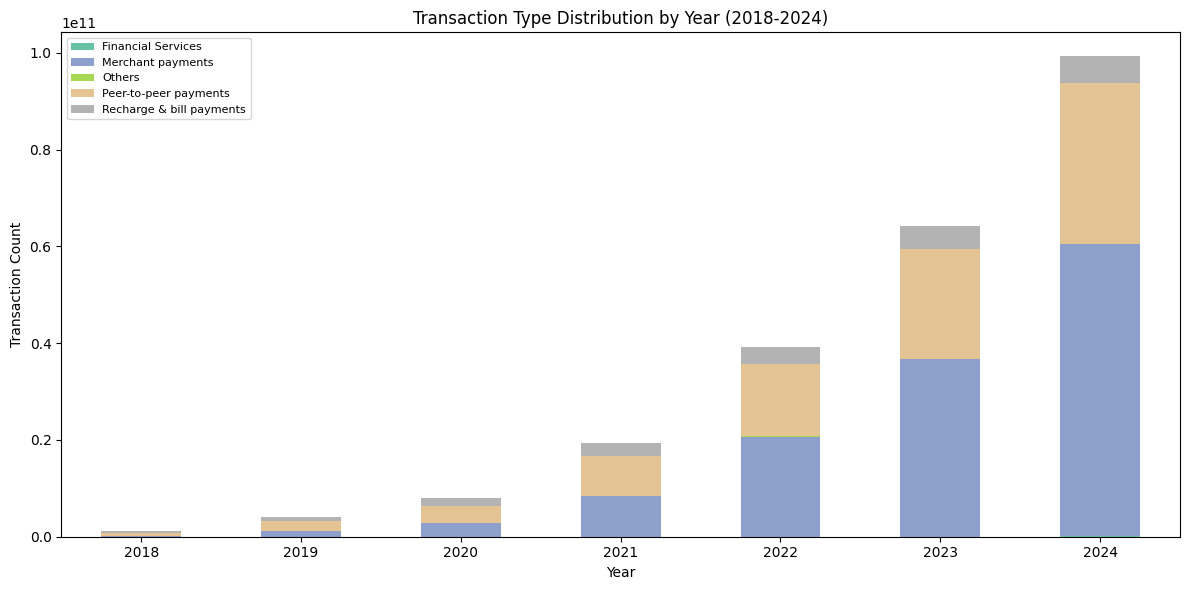

In [24]:
# Chart - 11 visualization code

# transaction type share over years - stacked bar chart
plt.figure(figsize=(12, 6))

type_year = df_agg_trans.groupby(["year", "transaction_type"])["transaction_count"].sum().unstack()

type_year.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")

plt.title("Transaction Type Distribution by Year (2018-2024)")
plt.xlabel("Year")
plt.ylabel("Transaction Count")
plt.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart was chosen to show both the overall growth
and the composition of transaction types in each year.
This makes it easy to see how the share of each payment category
has changed over time.

##### 2. What is/are the insight(s) found from the chart?

Merchant payments have consistently grown and now dominate the
transaction count in 2024. Peer-to-peer payments also grew but
their share relative to merchant payments has reduced over time.
Recharge and bill payments share has stayed small and consistent.
Financial Services and Others remain negligible throughout all years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The growing dominance of merchant payments is a positive sign
as it shows PhonePe is becoming the preferred payment method
at retail stores, online platforms and small businesses.
This is the most scalable segment for revenue growth.

The negative signal is that P2P payments which were a major share
in early years are now being overtaken by merchant payments.
While this is not bad, PhonePe must ensure P2P users do not
switch to competitors like GPay or BHIM for personal transfers.
Maintaining P2P loyalty through better UX and zero fee transfers
is important to retain this user base.

#### Chart - 12

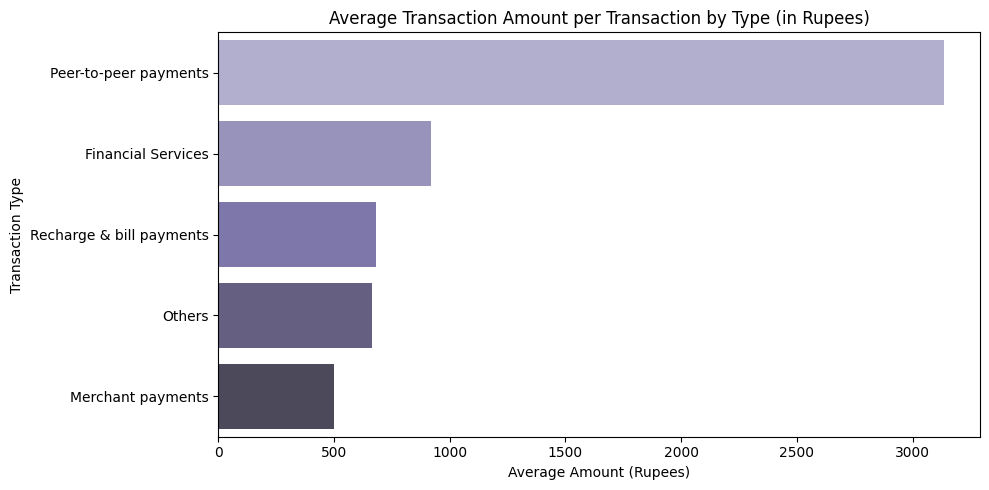

In [25]:
# Chart - 12 visualization code

# average transaction amount per transaction by type - bar chart
plt.figure(figsize=(10, 5))

avg_amount = df_agg_trans.groupby("transaction_type").apply(
    lambda x: (x["transaction_amount_cr"].sum() / x["transaction_count"].sum()) * 1e7
).sort_values(ascending=False)

sns.barplot(x=avg_amount.values, y=avg_amount.index, palette="Purples_d")

plt.title("Average Transaction Amount per Transaction by Type (in Rupees)")
plt.xlabel("Average Amount (Rupees)")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare the average rupee value per
transaction across different payment types. This gives a better
picture of transaction quality rather than just quantity.

##### 2. What is/are the insight(s) found from the chart?

Peer-to-peer payments have by far the highest average transaction
amount at around 3100 rupees per transaction. Financial Services
comes second at around 900 rupees. Merchant payments have the
lowest average at around 500 rupees which confirms that merchant
payments are mostly small daily purchases like groceries and food.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing the average transaction value per type helps PhonePe
design better products and risk models.

P2P having the highest average means these are serious money
transfers between individuals. PhonePe should offer instant
bank confirmation, transaction receipts and dispute resolution
features to build more trust for high value P2P transfers.

The negative signal is that Merchant payments having the lowest
average means PhonePe earns very little per merchant transaction.
To improve revenue PhonePe should introduce value added services
for merchants like analytics dashboards, loyalty programs and
business loans to monetize the high volume low value segment better.

#### Chart - 13

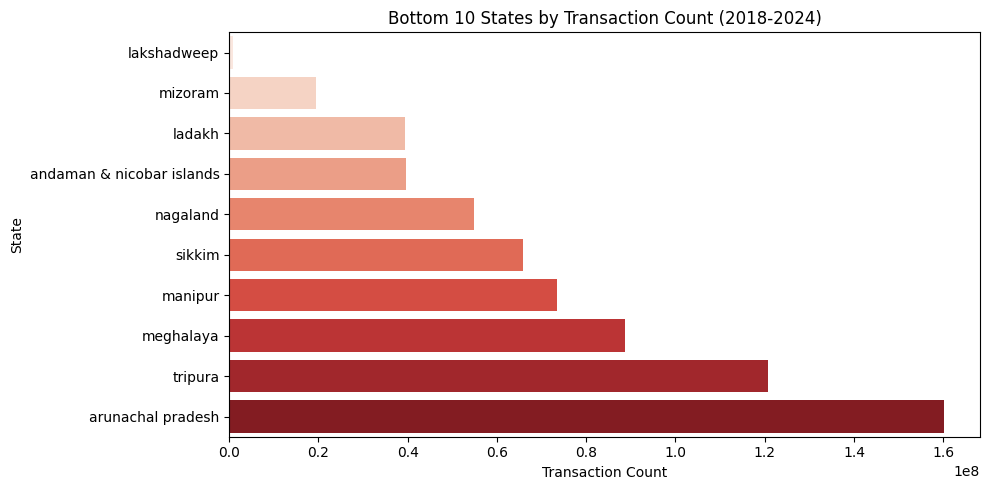

In [26]:
# Chart - 13 visualization code

# bottom 10 states by transaction count - bar chart
plt.figure(figsize=(10, 5))

bottom_states = df_map_trans.groupby("state")["transaction_count"].sum().sort_values(ascending=True).head(10)

sns.barplot(x=bottom_states.values, y=bottom_states.index, palette="Reds")

plt.title("Bottom 10 States by Transaction Count (2018-2024)")
plt.xlabel("Transaction Count")
plt.ylabel("State")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to identify the lowest performing states
in terms of transaction count. This helps find underserved markets
where PhonePe has very low penetration.

##### 2. What is/are the insight(s) found from the chart?

Lakshadweep has the lowest transaction count which makes sense
given its tiny population. Mizoram, Ladakh and Andaman & Nicobar
Islands follow. Most of the bottom 10 states are northeastern
states and union territories with small populations and limited
internet connectivity. These regions have very low digital
payment adoption compared to mainland India.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. While low population explains some of these numbers, states
like Nagaland, Manipur and Meghalaya have decent populations
but very low transaction counts. This points to a clear
infrastructure and awareness gap in northeastern India.

PhonePe can work with the government and local telcos to improve
internet connectivity and run awareness campaigns in these regions.
Capturing even a small share of these untapped markets could
add significant new users to the platform.

The negative signal is that if PhonePe ignores these regions
competitors with better local presence may establish dominance
making it very difficult for PhonePe to enter later.

#### Chart - 14 - Correlation Heatmap

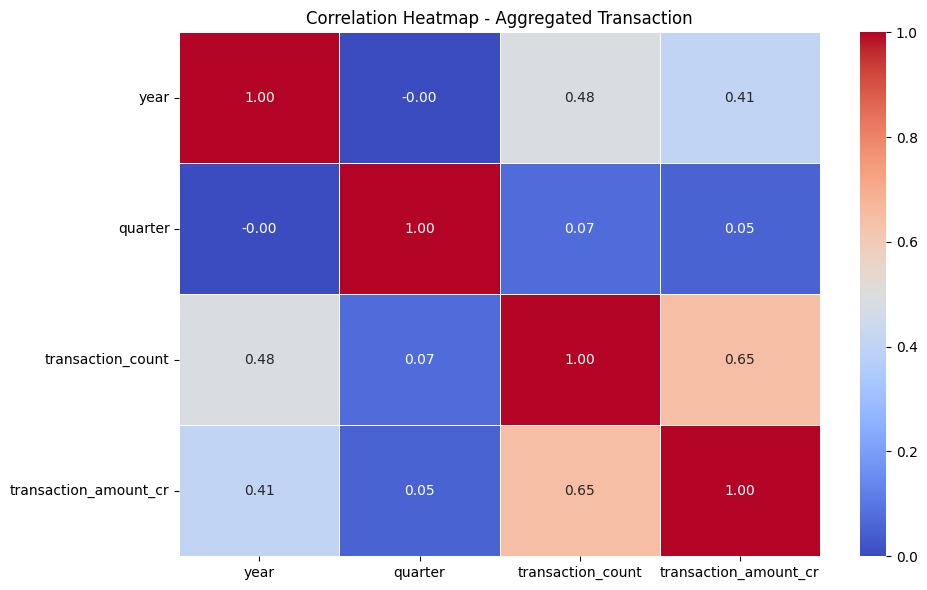

In [27]:
# Correlation Heatmap visualization code

# correlation heatmap between numerical columns
plt.figure(figsize=(10, 6))

combined = df_agg_trans[["year", "quarter", "transaction_count", "transaction_amount_cr"]].copy()

sns.heatmap(combined.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap - Aggregated Transaction")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen to understand the relationship
between numerical variables. It gives a quick visual summary
of how strongly each variable is related to the others.

##### 2. What is/are the insight(s) found from the chart?

Transaction count and transaction amount have a moderate positive
correlation of 0.65 meaning when transaction count increases
the amount also tends to increase. Year has a moderate correlation
with both transaction count and amount showing that both have
grown over time. Quarter has almost no correlation with count
or amount meaning seasonality is not a strong factor here.

#### Chart - 15 - Pair Plot

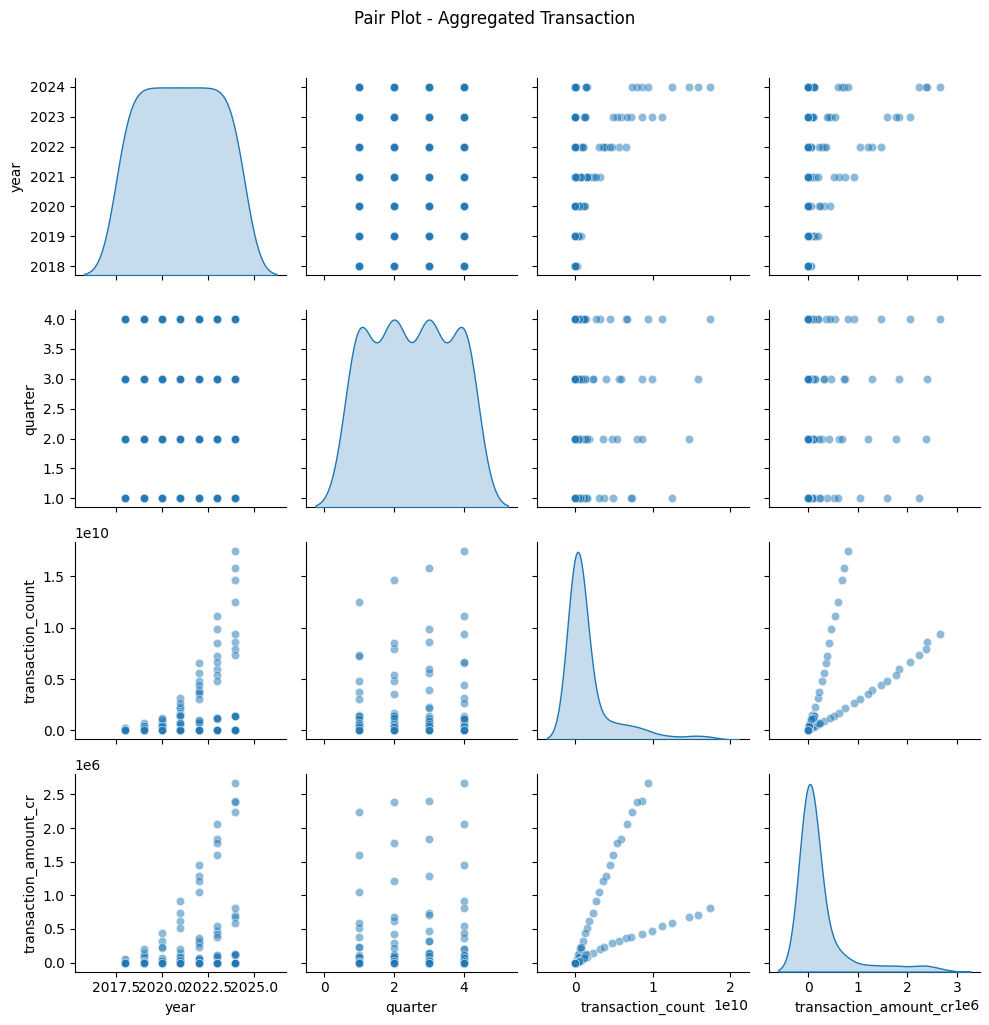

In [28]:
# Pair Plot visualization code
# pair plot to see relationships between all numerical variables
sns.pairplot(df_agg_trans[["year", "quarter", "transaction_count", "transaction_amount_cr"]],
             diag_kind="kde", plot_kws={"alpha": 0.5})

plt.suptitle("Pair Plot - Aggregated Transaction", y=1.02)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize the relationship between
all numerical variables at once. The diagonal shows the
distribution of each variable and the off diagonal plots
show scatter plots between every pair of variables.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot between transaction count and transaction amount
shows a clear linear relationship confirming the 0.65 correlation
from the heatmap. Year vs transaction count and year vs transaction
amount both show an upward trend confirming growth over time.
The KDE plots on the diagonal show that transaction count and
amount are both right skewed meaning most transactions are low
value but a few are very high value. Quarter distribution is
uniform showing equal representation of all four quarters in the data.

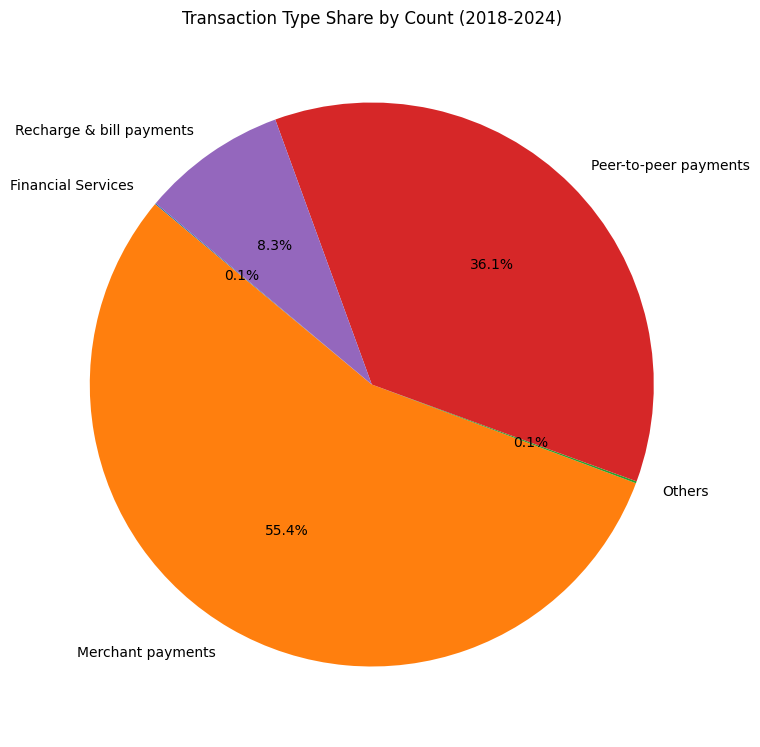

In [29]:
# Chart 16 - pie chart of transaction type share
plt.figure(figsize=(8, 8))

pie_data = df_agg_trans.groupby("transaction_type")["transaction_count"].sum()

plt.pie(pie_data.values, labels=pie_data.index, autopct="%1.1f%%", startangle=140)

plt.title("Transaction Type Share by Count (2018-2024)")
plt.tight_layout()
plt.show()

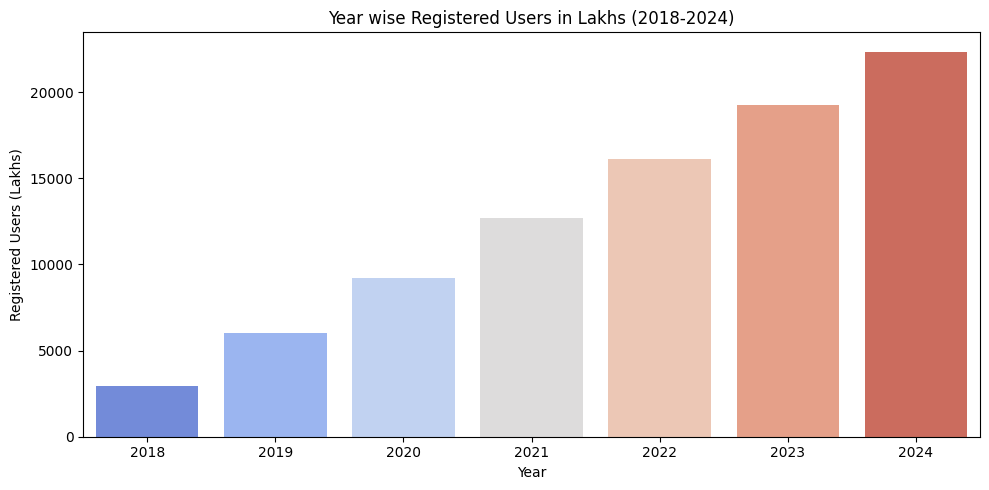

In [30]:
#Chart 17: year wise registered users growth - bar chart
plt.figure(figsize=(10, 5))

user_bar = df_agg_user.groupby("year")["registered_users_lakh"].sum()

sns.barplot(x=user_bar.index, y=user_bar.values, palette="coolwarm")

plt.title("Year wise Registered Users in Lakhs (2018-2024)")
plt.xlabel("Year")
plt.ylabel("Registered Users (Lakhs)")
plt.tight_layout()
plt.show()

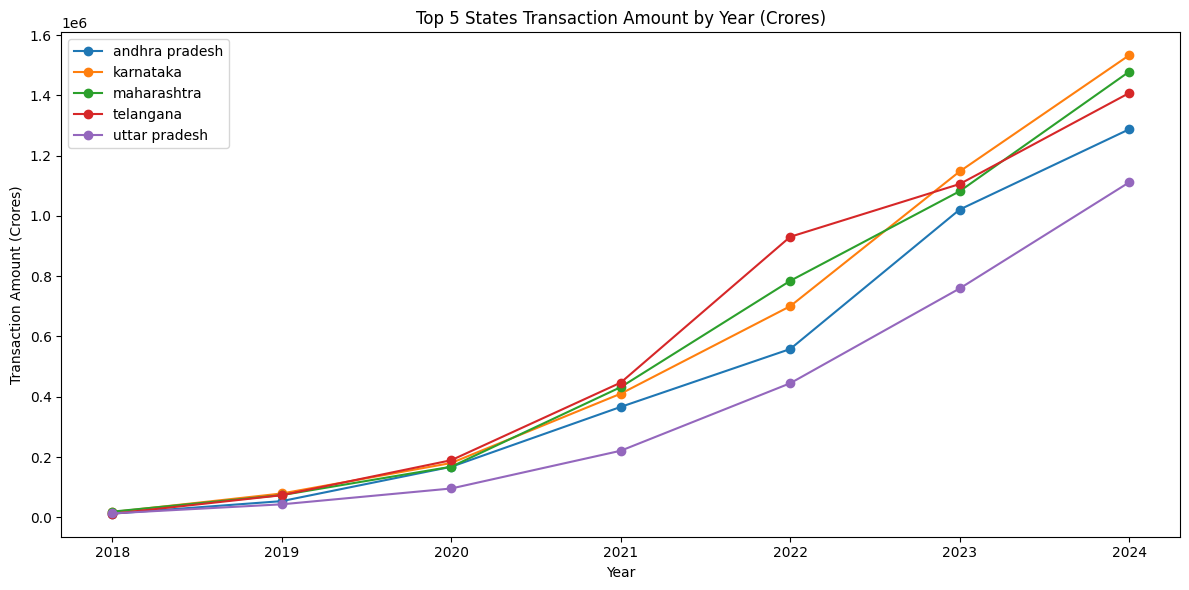

In [31]:
#Chart 18: top 5 states transaction amount year wise - line chart
plt.figure(figsize=(12, 6))

top5_states = df_map_trans.groupby("state")["transaction_amount_cr"].sum().sort_values(ascending=False).head(5).index

top5_data = df_map_trans[df_map_trans["state"].isin(top5_states)]
top5_grouped = top5_data.groupby(["year", "state"])["transaction_amount_cr"].sum().unstack()

for state in top5_grouped.columns:
    plt.plot(top5_grouped.index, top5_grouped[state], marker="o", label=state)

plt.title("Top 5 States Transaction Amount by Year (Crores)")
plt.xlabel("Year")
plt.ylabel("Transaction Amount (Crores)")
plt.legend()
plt.xticks(top5_grouped.index)
plt.tight_layout()
plt.show()

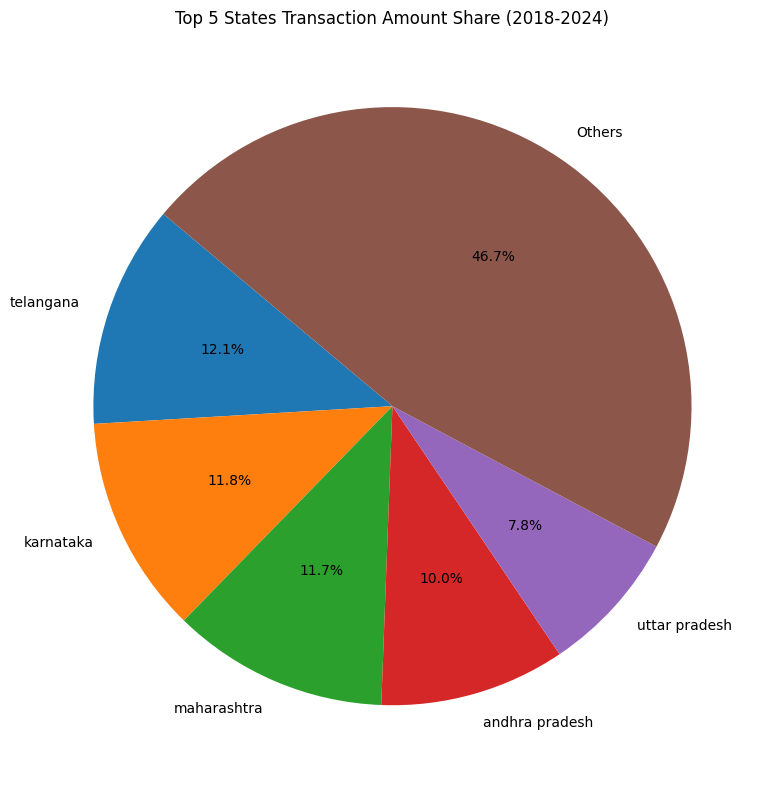

In [32]:
#Chart 19: transaction amount share by state - pie chart top 5
plt.figure(figsize=(8, 8))

state_pie = df_map_trans.groupby("state")["transaction_amount_cr"].sum().sort_values(ascending=False)
top5 = state_pie.head(5)
others = pd.Series({"Others": state_pie.iloc[5:].sum()})
final = pd.concat([top5, others])

plt.pie(final.values, labels=final.index, autopct="%1.1f%%", startangle=140)
plt.title("Top 5 States Transaction Amount Share (2018-2024)")
plt.tight_layout()
plt.show()

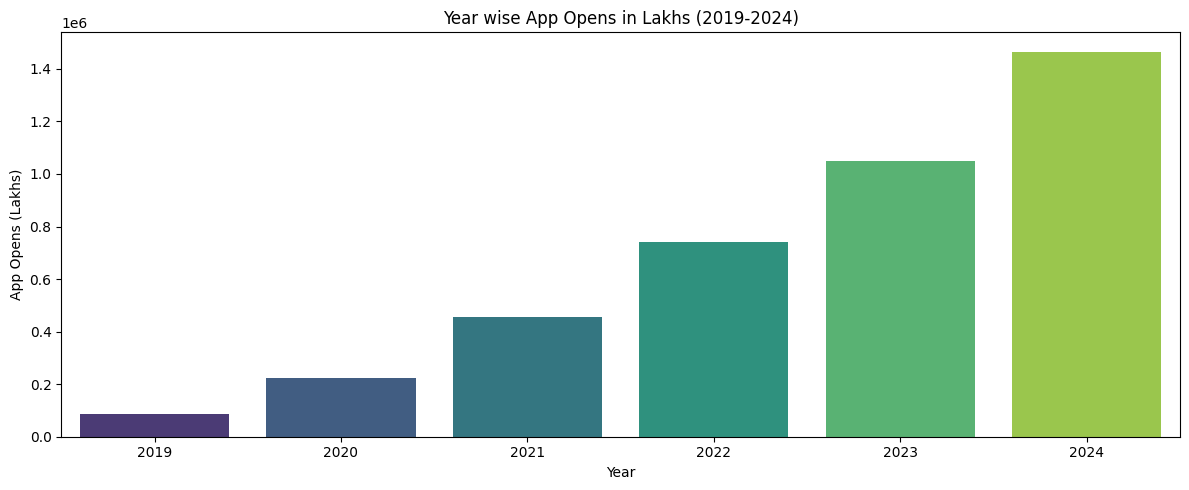

In [33]:
#Chart 20: app opens growth quarter wise - bar chart
plt.figure(figsize=(12, 5))

app_opens = df_agg_user[df_agg_user["app_opens_lakh"] > 0].groupby("year")["app_opens_lakh"].sum()

sns.barplot(x=app_opens.index, y=app_opens.values, palette="viridis")

plt.title("Year wise App Opens in Lakhs (2019-2024)")
plt.xlabel("Year")
plt.ylabel("App Opens (Lakhs)")
plt.tight_layout()
plt.show()

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis of PhonePe transaction data from 2018 to 2024,
here are the key suggestions to achieve the business objective:

1. Focus on Merchant Payments
Merchant payments have the highest transaction count. PhonePe should
aggressively onboard more small and medium merchants especially in
tier 2 and tier 3 cities to sustain this growth.

2. Push Financial Services
Financial Services has the lowest count and amount across all years.
PhonePe should actively promote loans, insurance and investment products
through in-app nudges and cashback offers to grow this segment.

3. Target Underperforming States
States like Mizoram, Nagaland, Manipur and Ladakh have very low
transaction counts. PhonePe should run regional language campaigns
and partner with local businesses to improve penetration in these areas.

4. Leverage Peak Quarter
Q4 consistently shows the highest transactions. PhonePe should plan
its biggest marketing campaigns, offers and new feature launches
around Q4 to maximize impact during the festive season.

5. Scale Infrastructure
Transaction count and amount are growing exponentially. PhonePe must
invest in server capacity, fraud detection and security systems to
handle the increasing load without any downtime or data breaches.

6. Improve P2P Experience
P2P payments have the highest average transaction value. Enhancing
security features, instant confirmations and dispute resolution for
P2P transfers will build stronger user trust for high value transactions.

# **Conclusion**

This project analyzed PhonePe transaction data from 2018 to 2024
using data extracted from the official PhonePe Pulse GitHub repository.

The analysis covered aggregated transaction data, user growth data
and state level transaction data across all years and quarters.

Key findings from the analysis:

PhonePe has shown extraordinary growth over 7 years with transaction
count growing nearly 10 times and transaction amount growing nearly
25 times from 2018 to 2024. This confirms that digital payments
have become mainstream in India.

Merchant payments dominate in transaction count while Peer-to-peer
payments dominate in transaction amount showing two very different
but equally important use cases on the platform.

Maharashtra, Karnataka and Telangana are the top performing states
while northeastern states and union territories remain largely
underserved markets with huge growth potential.

Q4 is consistently the strongest quarter driven by festive season
spending while Q1 shows the lowest activity indicating a post
festive slowdown.

Registered users have grown linearly to over 220 crore by 2024
while app opens have grown exponentially showing very high
engagement and daily active usage among existing users.

Financial Services remains a massively underdeveloped segment
and represents the biggest growth opportunity for PhonePe
going forward.

Overall PhonePe is in a very strong position in India's digital
payment ecosystem and with the right focus on underserved states,
financial products and infrastructure scaling it can continue
to dominate the market for years to come.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [34]:
import sqlite3

# creating sqlite database
conn = sqlite3.connect("phonepe.db")
cursor = conn.cursor()

print("✅ Database connected successfully!")

✅ Database connected successfully!


In [35]:
# creating tables in sqlite database

# table 1 - aggregated transaction
cursor.execute("""
    CREATE TABLE IF NOT EXISTS aggregated_transaction (
        year INTEGER,
        quarter INTEGER,
        transaction_type TEXT,
        transaction_count BIGINT,
        transaction_amount REAL
    )
""")

# table 2 - aggregated user
cursor.execute("""
    CREATE TABLE IF NOT EXISTS aggregated_user (
        year INTEGER,
        quarter INTEGER,
        registered_users BIGINT,
        app_opens BIGINT
    )
""")

# table 3 - map transaction
cursor.execute("""
    CREATE TABLE IF NOT EXISTS map_transaction (
        year INTEGER,
        quarter INTEGER,
        state TEXT,
        transaction_count BIGINT,
        transaction_amount REAL
    )
""")

conn.commit()
print("✅ All tables created successfully!")

✅ All tables created successfully!


In [36]:
# inserting data into tables

# inserting aggregated transaction data
df_agg_trans[["year", "quarter", "transaction_type", "transaction_count", "transaction_amount"]].to_sql(
    "aggregated_transaction", conn, if_exists="replace", index=False
)
print(f"✅ Aggregated Transaction inserted: {len(df_agg_trans)} rows")

# inserting aggregated user data
df_agg_user[["year", "quarter", "registered_users", "app_opens"]].to_sql(
    "aggregated_user", conn, if_exists="replace", index=False
)
print(f"✅ Aggregated User inserted: {len(df_agg_user)} rows")

# inserting map transaction data
df_map_trans[["year", "quarter", "state", "transaction_count", "transaction_amount"]].to_sql(
    "map_transaction", conn, if_exists="replace", index=False
)
print(f"✅ Map Transaction inserted: {len(df_map_trans)} rows")

conn.commit()
print("\n✅ All data inserted successfully!")

✅ Aggregated Transaction inserted: 140 rows
✅ Aggregated User inserted: 28 rows
✅ Map Transaction inserted: 1008 rows

✅ All data inserted successfully!


In [37]:
# SQL Query 1 - top 5 states by total transaction amount
query1 = """
    SELECT state,
           SUM(transaction_count) as total_count,
           ROUND(SUM(transaction_amount) / 1e7, 2) as total_amount_cr
    FROM map_transaction
    GROUP BY state
    ORDER BY total_amount_cr DESC
    LIMIT 5
"""

result1 = pd.read_sql_query(query1, conn)
print("Top 5 States by Transaction Amount:")
display(result1)

Top 5 States by Transaction Amount:


,state,total_count,total_amount_cr
0,telangana,26174684592,4165595.56
1,karnataka,30970946279,4067872.18
2,maharashtra,31985208732,4037419.57
3,andhra pradesh,18918696723,3466908.05
4,uttar pradesh,18523603727,2688521.22


In [38]:
# SQL Query 2 - most popular transaction type
query2 = """
    SELECT transaction_type,
           SUM(transaction_count) as total_count,
           ROUND(SUM(transaction_amount) / 1e7, 2) as total_amount_cr
    FROM aggregated_transaction
    GROUP BY transaction_type
    ORDER BY total_count DESC
"""

result2 = pd.read_sql_query(query2, conn)
print("Transaction Type wise Summary:")
display(result2)

Transaction Type wise Summary:


,transaction_type,total_count,total_amount_cr
0,Merchant payments,130239077540,6534013.05
1,Peer-to-peer payments,85032730880,26652852.53
2,Recharge & bill payments,19596835011,1333882.25
3,Others,262050922,17428.17
4,Financial Services,154210218,14202.09


In [39]:
# SQL Query 3 - year with highest transactions

query3 ="""
    SELECT year,
           SUM(transaction_count) as total_count,
           ROUND(SUM(transaction_amount) / 1e7, 2) as total_amount_cr
    FROM aggregated_transaction
    GROUP BY year
    ORDER BY total_count DESC
"""

result3 = pd.read_sql_query(query3, conn)
print("\nYear wise Summary:")
display(result3)


Year wise Summary:


,year,total_count,total_amount_cr
0,2024,99303614318,12962486.76
1,2023,64257337706,9449237.39
2,2022,39301426326,6426664.85
3,2021,19288489296,3459889.21
4,2020,7973993463,1464122.23
5,2019,4079836517,627671.72
6,2018,1080206945,162305.93


In [40]:
# SQL Query 4 - which quarter is most active
query4 = """
    SELECT quarter,
           SUM(transaction_count) as total_count,
           ROUND(SUM(transaction_amount) / 1e7, 2) as total_amount_cr
    FROM aggregated_transaction
    GROUP BY quarter
    ORDER BY total_count DESC
"""

result4 = pd.read_sql_query(query4, conn)
print("\nQuarter wise Summary:")
display(result4)



Quarter wise Summary:


,quarter,total_count,total_amount_cr
0,4,70638432579,10191004.16
1,3,62141310043,8823343.92
2,2,54660187891,8202468.64
3,1,47844974058,7335561.36
